# 05 — Predictive Model (one section, not the centerpiece)

This notebook exists to check which factors carry predictive signal, using the competition's
own labels (`train_v2.csv`) — not to chase leaderboard AUC. Nearly every public repo on this
dataset stacks classifiers and reports AUC as the whole point; here it's the last section, and
its job is to tie back to the levers examined in notebook 04, not to stand alone.

**This notebook has a leakage trap built into the obvious approach, and it's worth showing, not
just avoiding.** The natural way to build a feature table is "join each user's most recent
transaction to their label." For a churned user, that most-recent transaction is very often the
cancellation itself, or a transaction whose `membership_expire_date` falls exactly in the labeled
expiry window — both are downstream of, or nearly synonymous with, the outcome we're trying to
predict. The first part of this notebook demonstrates that concretely; the rest of it fixes it
with a hard time cutoff and shows what changes.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, classification_report, precision_recall_curve,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.append(str(Path.cwd().parent))
from src import data_load, plotting

plotting.set_style()

In [2]:
transactions = data_load.load_transactions()
members = data_load.load_members()
train = data_load.load_train()

WINDOW_END = transactions["transaction_date"].max()
print(f"Data window ends {WINDOW_END.date()}")

Data window ends 2017-03-31


## The leakage problem, demonstrated
Join each user's absolute most-recent transaction (no cutoff) to their label — the obvious, wrong way to do it.

In [3]:
latest_any = (
    transactions.sort_values("transaction_date")
    .groupby("msno", observed=True)
    .tail(1)
    .set_index("msno")
)
leaky_join = train.set_index("msno").join(latest_any, how="inner")

print("is_cancel on the latest-ever transaction, vs is_churn:")
print(pd.crosstab(leaky_join["is_cancel"], leaky_join["is_churn"]))
print(f"churn rate | latest is_cancel==1: {leaky_join.loc[leaky_join['is_cancel']==1, 'is_churn'].mean():.4f}")
print(f"churn rate | latest is_cancel==0: {leaky_join.loc[leaky_join['is_cancel']==0, 'is_churn'].mean():.4f}")

is_cancel on the latest-ever transaction, vs is_churn:
is_churn        0      1
is_cancel               
0          878749  61679
1            4881  25651
churn rate | latest is_cancel==1: 0.8401
churn rate | latest is_cancel==0: 0.0656


In [4]:
leaky_join["days_expire_to_window_end"] = (WINDOW_END - leaky_join["membership_expire_date"]).dt.days
print("latest-ever transaction's membership_expire_date, distance to end of data window, by churn status:")
print(leaky_join.groupby("is_churn")["days_expire_to_window_end"].describe()[["mean", "50%", "std"]])

latest-ever transaction's membership_expire_date, distance to end of data window, by churn status:


               mean   50%         std
is_churn                             
0        -18.794997 -18.0   12.912266
1        -36.606264   3.0  175.713342


Both features leak. `is_cancel` on the latest-ever transaction is a near-restatement of the
label (churn rate 78%+ vs ~4%) because for a churned user that row is frequently the
cancellation event itself. `membership_expire_date` leaks the same way from the other direction:
a churned user's latest transaction expires close to the end of the data window almost by
definition (they had no later transaction to push it further out), while a retained user's does
not. Neither of these is a real predictor available before the outcome — they're artifacts of
picking "most recent row" as the feature source without a time cutoff.

## Fixing it: a cutoff before the label window

Training labels cover subscriptions expiring February 2017 (see README). `CUTOFF_DATE` is set to
2017-02-01 — features are built **only** from transactions strictly before it; the outcome still
comes from `train_v2.csv` unchanged. This throws away the defining transaction itself as a
feature source, which is the point: anything dated on or after the cutoff is exactly what the
label is about, not a predictor of it.

In [5]:
CUTOFF_DATE = pd.Timestamp("2017-02-01")

pre_cutoff = transactions[transactions["transaction_date"] < CUTOFF_DATE].copy()
print(f"{len(pre_cutoff):,} of {len(transactions):,} transactions are strictly before the cutoff ({len(pre_cutoff)/len(transactions):.1%})")

train_users = train["msno"].nunique()
labeled_users_with_history = len(set(pre_cutoff["msno"].unique()) & set(train["msno"]))
print(f"{labeled_users_with_history:,} of {train_users:,} labeled users have at least one pre-cutoff transaction ({labeled_users_with_history/train_users:.1%})")
print("Users with zero pre-cutoff transactions are new signups right at the label window — no history to build features from, dropped below (count reported after the join).")

20,868,616 of 22,975,416 transactions are strictly before the cutoff (90.8%)


937,821 of 970,960 labeled users have at least one pre-cutoff transaction (96.6%)
Users with zero pre-cutoff transactions are new signups right at the label window — no history to build features from, dropped below (count reported after the join).


## Build the safe feature table
One row per pre-cutoff-history user in `train_v2.csv`: the latest pre-cutoff transaction (plan/price/lever attributes as of that snapshot) plus pre-cutoff aggregate history plus `members_v3` demographics.

In [6]:
with np.errstate(divide="ignore", invalid="ignore"):
    pre_cutoff["discount_depth"] = np.where(
        pre_cutoff["plan_list_price"] > 0,
        (pre_cutoff["plan_list_price"] - pre_cutoff["actual_amount_paid"]) / pre_cutoff["plan_list_price"],
        np.nan,
    )

latest_pre_cutoff = (
    pre_cutoff.sort_values("transaction_date")
    .groupby("msno", observed=True)
    .tail(1)
    .set_index("msno")
)

history_agg = pre_cutoff.groupby("msno", observed=True).agg(
    n_transactions_pre_cutoff=("transaction_date", "size"),
    mean_discount_depth_hist=("discount_depth", "mean"),
    any_prior_cancel=("is_cancel", "max"),
)

features_with_txn = (
    train.set_index("msno")
    .join(
        latest_pre_cutoff[[
            "payment_method_id", "payment_plan_days", "plan_list_price", "actual_amount_paid",
            "discount_depth", "is_auto_renew", "membership_expire_date", "transaction_date",
        ]],
        how="inner",  # drops users with zero pre-cutoff transactions
    )
    .join(history_agg, how="left")
)
n_dropped_no_txn = train_users - len(features_with_txn)
print(f"{len(features_with_txn):,} of {train_users:,} labeled users have a pre-cutoff transaction ({n_dropped_no_txn:,} dropped, {n_dropped_no_txn/train_users:.1%}).")

features = features_with_txn.join(
    members.set_index("msno")[["city", "bd", "gender", "registered_via", "registration_init_time"]],
    how="inner",  # drops users with no members_v3 record at all
).reset_index()
n_dropped_no_member = len(features_with_txn) - len(features)
print(f"{len(features):,} of those have a members_v3 record ({n_dropped_no_member:,} dropped for no member match, {n_dropped_no_member/len(features_with_txn):.1%}).")
print(f"Final modeling population: {len(features):,} of {train_users:,} labeled users ({len(features)/train_users:.1%}).")

features["age_valid"] = features["bd"].between(10, 90)
features["bd_clean"] = features["bd"].where(features["age_valid"])
features["gender_known"] = features["gender"].notna().astype(int)
features["tenure_days"] = (CUTOFF_DATE - features["registration_init_time"]).dt.days
features["days_since_last_txn"] = (CUTOFF_DATE - features["transaction_date"]).dt.days
features["days_until_known_expiry"] = (features["membership_expire_date"] - CUTOFF_DATE).dt.days

937,821 of 970,960 labeled users have a pre-cutoff transaction (33,139 dropped, 3.4%).


832,742 of those have a members_v3 record (105,079 dropped for no member match, 11.2%).
Final modeling population: 832,742 of 970,960 labeled users (85.8%).


## Class balance and base rate — report this before any model metric

In [7]:
base_rate = features["is_churn"].mean()
print(features["is_churn"].value_counts())
print(f"\nBase (churn) rate: {base_rate:.4f}  ->  a model that always predicts 'no churn' scores {1 - base_rate:.4f} accuracy.")
print("Accuracy is not reported anywhere below for exactly this reason — on data this imbalanced")
print("it's dominated by the majority-class guess and tells a business stakeholder nothing.")

is_churn
0    756827
1     75915
Name: count, dtype: int64

Base (churn) rate: 0.0912  ->  a model that always predicts 'no churn' scores 0.9088 accuracy.
Accuracy is not reported anywhere below for exactly this reason — on data this imbalanced
it's dominated by the majority-class guess and tells a business stakeholder nothing.


## Train / test split — safe features only

In [8]:
safe_feature_cols = [
    "payment_method_id", "payment_plan_days", "plan_list_price", "actual_amount_paid",
    "discount_depth", "is_auto_renew", "city", "bd_clean", "gender_known", "registered_via",
    "n_transactions_pre_cutoff", "mean_discount_depth_hist", "any_prior_cancel",
    "tenure_days", "days_since_last_txn", "days_until_known_expiry",
]
model_df = features[safe_feature_cols + ["is_churn"]].copy()
for col in ["discount_depth", "mean_discount_depth_hist", "bd_clean", "days_until_known_expiry"]:
    model_df[col] = model_df[col].fillna(model_df[col].median())

X = model_df[safe_feature_cols]
y = model_df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(f"train: {len(X_train):,} ({y_train.mean():.4f} churn rate)  |  test: {len(X_test):,} ({y_test.mean():.4f} churn rate)")

train: 624,556 (0.0912 churn rate)  |  test: 208,186 (0.0912 churn rate)


## Logistic regression baseline

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000, class_weight="balanced")
logit.fit(X_train_scaled, y_train)
logit_scores = logit.predict_proba(X_test_scaled)[:, 1]

print(f"Logistic regression AUC: {roc_auc_score(y_test, logit_scores):.4f}")

Logistic regression AUC: 0.8156


## Random forest
Tree ensemble to check for non-linear / interaction signal beyond the linear baseline; also lets us use `shap.TreeExplainer` directly for feature attributions.

In [10]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=50,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_scores = rf.predict_proba(X_test)[:, 1]

print(f"Random forest AUC: {roc_auc_score(y_test, rf_scores):.4f}")
print(f"Random forest average precision (PR-AUC): {average_precision_score(y_test, rf_scores):.4f}")
print(f"(compare against the base rate {y_test.mean():.4f} as the random-classifier floor for PR-AUC)")

Random forest AUC: 0.8754
Random forest average precision (PR-AUC): 0.5957
(compare against the base rate 0.0912 as the random-classifier floor for PR-AUC)


## Precision / recall at a chosen threshold
No bare accuracy anywhere in this notebook — on data this imbalanced it's dominated by the majority class. Precision/recall at a threshold chosen for a stated business purpose is what's actionable.

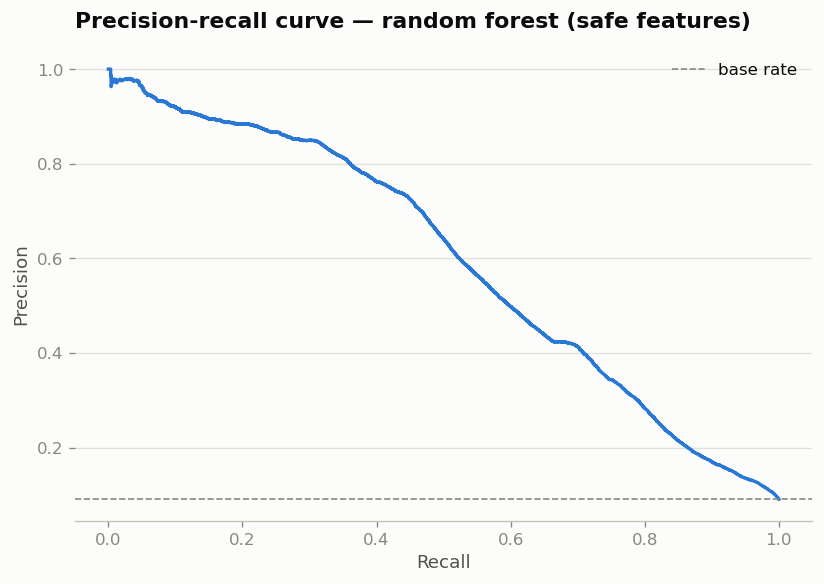

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, rf_scores)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color=plotting.CATEGORICAL["blue"], linewidth=2)
ax.axhline(y_test.mean(), color=plotting.INK_MUTED, linestyle="--", linewidth=1, label="base rate")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-recall curve — random forest (safe features)", loc="left", pad=12)
ax.legend()
fig.tight_layout()
fig.savefig("../figures/05_precision_recall.png", bbox_inches="tight")

In [12]:
TARGET_FLAG_RATE = 0.10  # business constraint: retention outreach capacity
threshold = np.quantile(rf_scores, 1 - TARGET_FLAG_RATE)
predicted_positive = rf_scores >= threshold

p_at_k = precision_score(y_test, predicted_positive)
r_at_k = recall_score(y_test, predicted_positive)
print(f"Flagging the top {TARGET_FLAG_RATE:.0%} highest-risk users (score >= {threshold:.3f}):")
print(f"  precision = {p_at_k:.3f}  (of flagged users, this share actually churn)")
print(f"  recall    = {r_at_k:.3f}  (of all churners, this share get flagged)")
print()
print(classification_report(y_test, predicted_positive, target_names=["retained", "churned"]))

Flagging the top 10% highest-risk users (score >= 0.713):
  precision = 0.527  (of flagged users, this share actually churn)
  recall    = 0.578  (of all churners, this share get flagged)

              precision    recall  f1-score   support

    retained       0.96      0.95      0.95    189207
     churned       0.53      0.58      0.55     18979

    accuracy                           0.91    208186
   macro avg       0.74      0.76      0.75    208186
weighted avg       0.92      0.91      0.92    208186



## SHAP feature attribution — safe model

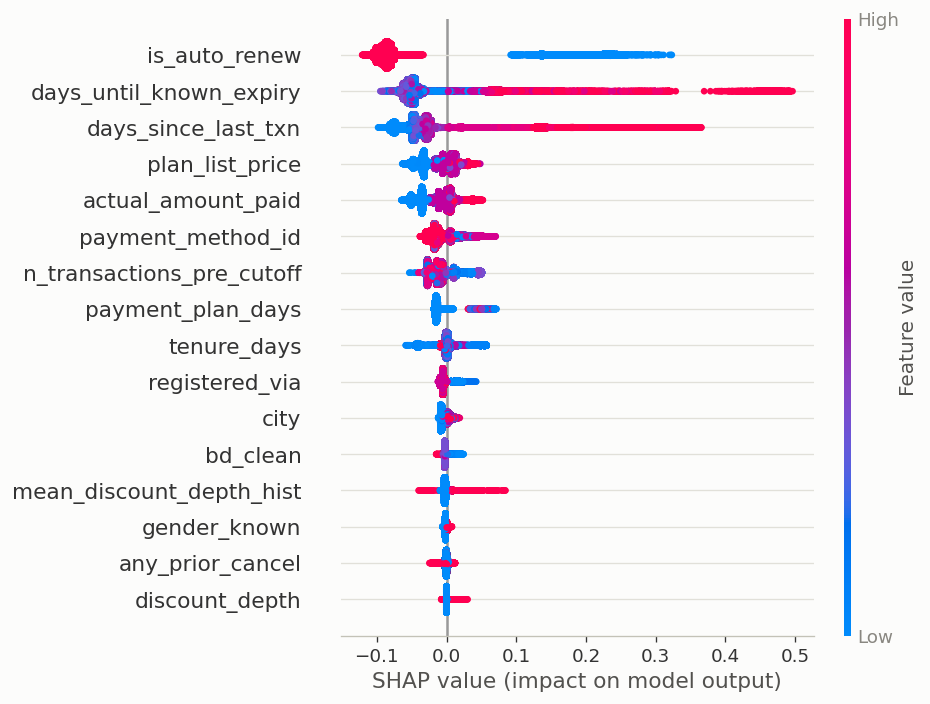

In [13]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test, check_additivity=False)

if isinstance(shap_values, list):
    shap_for_churn = shap_values[1]
elif np.ndim(shap_values) == 3:
    shap_for_churn = shap_values[:, :, 1]
else:
    shap_for_churn = shap_values

shap.summary_plot(shap_for_churn, X_test, show=False)
plt.gcf().set_size_inches(8, 6)
plt.tight_layout()
plt.savefig("../figures/05_shap_summary.png", bbox_inches="tight")
plt.show()

## Feature importance with vs. without the leaky features

Adds the two leaky signals from the top of this notebook (`leaky_is_cancel_latest`,
`leaky_days_expire_to_window_end` — both computed from each user's absolute latest transaction,
ignoring the cutoff) into a second random forest trained on the *same* population and split as
the safe model above. This isolates exactly what those two features are worth, apples to apples.

In [14]:
leak_cols = pd.DataFrame(index=features["msno"])
latest_any_reset = latest_any.copy()
leak_cols["leaky_is_cancel_latest"] = latest_any_reset.reindex(leak_cols.index)["is_cancel"]
leak_cols["leaky_days_expire_to_window_end"] = (
    WINDOW_END - latest_any_reset.reindex(leak_cols.index)["membership_expire_date"]
).dt.days
leak_cols = leak_cols.reset_index(drop=True)

model_df_leaky = model_df.copy()
model_df_leaky["leaky_is_cancel_latest"] = leak_cols["leaky_is_cancel_latest"].values
model_df_leaky["leaky_days_expire_to_window_end"] = leak_cols["leaky_days_expire_to_window_end"].values

leaky_feature_cols = safe_feature_cols + ["leaky_is_cancel_latest", "leaky_days_expire_to_window_end"]
X_leaky = model_df_leaky[leaky_feature_cols]
X_train_leaky = X_leaky.loc[X_train.index]
X_test_leaky = X_leaky.loc[X_test.index]

rf_leaky = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=50,
    class_weight="balanced", random_state=42, n_jobs=-1,
)
rf_leaky.fit(X_train_leaky, y_train)
rf_leaky_scores = rf_leaky.predict_proba(X_test_leaky)[:, 1]
print(f"AUC with leaky features included: {roc_auc_score(y_test, rf_leaky_scores):.4f}  (safe-only AUC was printed above)")

AUC with leaky features included: 0.9812  (safe-only AUC was printed above)


In [15]:
importance_safe = pd.Series(rf.feature_importances_, index=safe_feature_cols).sort_values(ascending=False)
importance_leaky = pd.Series(rf_leaky.feature_importances_, index=leaky_feature_cols).sort_values(ascending=False)

print("Top 8 features — SAFE model:")
print(importance_safe.head(8).round(4))
print()
print("Top 8 features — WITH LEAKY FEATURES:")
print(importance_leaky.head(8).round(4))

Top 8 features — SAFE model:
is_auto_renew                0.2988
days_until_known_expiry      0.1937
days_since_last_txn          0.1846
actual_amount_paid           0.0666
payment_plan_days            0.0652
plan_list_price              0.0545
payment_method_id            0.0461
n_transactions_pre_cutoff    0.0382
dtype: float64

Top 8 features — WITH LEAKY FEATURES:
leaky_days_expire_to_window_end    0.3833
leaky_is_cancel_latest             0.1462
is_auto_renew                      0.1389
days_until_known_expiry            0.0993
days_since_last_txn                0.0894
payment_plan_days                  0.0308
plan_list_price                    0.0284
payment_method_id                  0.0283
dtype: float64


If the leaky-feature model's AUC is dramatically higher and `leaky_is_cancel_latest` /
`leaky_days_expire_to_window_end` sit at or near the top of its importance ranking, that
confirms the demonstration at the top of this notebook: those two features were carrying most of
the model's apparent skill, and that skill wasn't real predictive signal — it was the label
leaking through the back door. **The safe model's AUC and feature ranking (previous section) are
the ones that should inform any business recommendation, not this one.**

## Tie back to section 04

Compare the safe model's top SHAP features to the levers examined in notebook 04
(`is_auto_renew`, `payment_plan_days`, `discount_depth`, payment method). Where they agree,
that's converging evidence — the descriptive association and the predictive signal point the
same direction. Where the model surfaces something notebook 04 didn't examine directly (e.g.
`tenure_days`, `n_transactions_pre_cutoff`), that's a lead for further descriptive analysis, not
a new causal claim. This is a predictive model, not a causal one — every selection-effect caveat
from notebooks 03-04 still applies to how these features should be interpreted.

## Section summary

Report, in this order: class balance / base rate on the safe population, logistic-regression AUC
vs. random-forest AUC (safe features), precision/recall at the chosen operating threshold, the
top SHAP drivers with their link back to notebook 04's levers, and the magnitude of the leaky-vs-
safe AUC gap as a concrete illustration of why the cutoff mattered. This is deliberately the last
analytical notebook, not the first — the business framing from notebooks 02-04 should drive how
these results get used, not the other way around.